In [14]:
# given a CircuitSentence, returns the LP problem constraints
# resembles lp_constraints/scipy_constraints.py/OrderedDefinedISAConstraints
# write a less generic version of the LP formalism for GULPS
# adapted from lp_constraints/lp_constraints.py
#              lp_constraints/qlr.py
#              lp_constraints/scipy_constraints.py
from typing import List, Tuple
import numpy as np
from scipy.optimize import linprog
from gulps.qlr import len_qlr, qlr_inequalities
from gulps.invariants import GateInvariants, LEN_GATE_INVARIANTS


class MinimalOrderedISAConstraints:
    """Minimal LP constraints for ordered, defined ISA sequences."""

    _ci_block, _gi_block, _ciplus1_block, _bi = qlr_inequalities

    def __init__(self, isa_sequence: List[GateInvariants]):
        self.isa_sequence = isa_sequence
        self.n = len(isa_sequence)
        self.num_ineq = len_qlr * (self.n - 1)
        self.num_params = LEN_GATE_INVARIANTS * (self.n - 2)
        self.last_iter_ct = np.zeros(len_qlr)
        self._setup_model()

    def _setup_model(self):
        self.c = np.zeros(self.num_params)  # objective: minimize zero
        self.A_ub, self.b_ub = self._setup_inequalities()
        self.A_eq, self.b_eq = None, None  # no equalities

    def _setup_inequalities(self):
        A_ub = np.zeros((self.num_ineq, self.num_params))
        b_ub = np.zeros(self.num_ineq)

        for i in range(self.n - 1):
            rows = slice(len_qlr * i, len_qlr * (i + 1))

            # c_i block
            if i > 0:
                offset = LEN_GATE_INVARIANTS * (i - 1)
                A_ub[rows, offset : offset + LEN_GATE_INVARIANTS] += self._ci_block

            # g_i contribution
            gi_contrib = np.dot(self._gi_block, self.isa_sequence[i + 1].monodromy)
            if i == 0:
                gi_contrib += np.dot(self._ci_block, self.isa_sequence[i].monodromy)
            b_ub[rows] += self._bi - gi_contrib

            # c_{i+1} block
            if i < self.n - 2:
                offset = LEN_GATE_INVARIANTS * i
                A_ub[rows, offset : offset + LEN_GATE_INVARIANTS] += self._ciplus1_block

        return A_ub, b_ub

    def set_target(self, target_gate: GateInvariants):
        # avoid reconstructing all of b_ub by tracking the last set target gate
        # when setting a new target, remove the contribution of the previous target
        self._target_def = target_gate.monodromy
        ct = np.dot(self._ciplus1_block, self._target_def)
        self.b_ub[-len_qlr:] += self.last_iter_ct - ct
        self.last_iter_ct = ct

    def solve(self, log_output=False):
        result = linprog(
            c=self.c,
            A_ub=self.A_ub,
            b_ub=self.b_ub,
            method="highs",
            options={"disp": log_output},
        )
        if result.success:
            return self._extract_solution(result)
        return None, None

    def _extract_solution(self, result):
        c_vec = result.x
        full_c_vec = np.concatenate(
            (
                np.zeros(LEN_GATE_INVARIANTS),
                self.isa_sequence[0].monodromy,
                c_vec,
                self._target_def,
            )
        )
        mono_points = list(zip(*[iter(full_c_vec)] * LEN_GATE_INVARIANTS))
        intermediate_invariants = []
        for point in mono_points:
            intermediate_invariants.append(GateInvariants(point))
        return self.isa_sequence, intermediate_invariants

In [15]:
from qiskit.circuit.library import CXGate, SwapGate, iSwapGate

isa_sequence = [
    GateInvariants.from_unitary(iSwapGate().power(1 / 2)),
    GateInvariants.from_unitary(iSwapGate().power(1 / 2)),
    GateInvariants.from_unitary(iSwapGate().power(1 / 2)),
]
constraints = MinimalOrderedISAConstraints(isa_sequence)

<Axes3D: xlabel='$c_1$', ylabel='$c_2$', zlabel='$c_3$'>

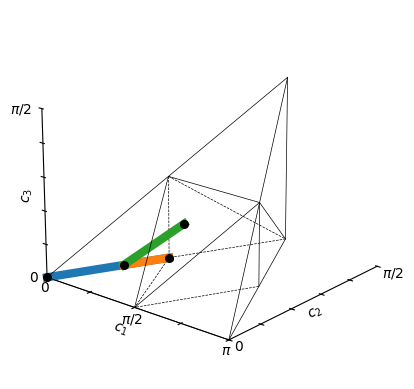

In [16]:
from gulps.visualize import render_path
from qiskit.quantum_info.random import random_unitary

u = random_unitary(4)
# u = SwapGate().to_matrix()
gi = GateInvariants.from_unitary(u)
constraints.set_target(gi)

sentence, intermediates = constraints.solve(log_output=False)
if sentence is None:
    constraints.set_target(gi.rho_reflect())
    sentence, intermediates = constraints.solve(log_output=False)

render_path(intermediates)